In [1]:
# Pandas and Numpy libraries
import pandas as pd
import numpy as np
# For preprocessing the data
from sklearn import preprocessing
# To split the dataset into train and test datasets
from sklearn.model_selection import train_test_split
# To model the Gaussian Navie Bayes classifier
from sklearn.naive_bayes import GaussianNB
# To calculate the accuracy score of the model
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
import warnings 
warnings.filterwarnings( "ignore")

In [2]:
df=pd.read_excel("Election_Data_1.xlsx")

In [3]:
df.head()

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,1,Labour,43,3,3,4,1,2,2,female
1,2,Labour,36,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,2,male
3,4,Labour,24,4,2,2,1,4,0,female
4,5,Labour,41,2,2,1,1,6,2,male


In [4]:
df.shape

(1525, 10)

In [5]:
df.isnull().sum()

Unnamed: 0                 0
vote                       0
age                        0
economic.cond.national     0
economic.cond.household    0
Blair                      0
Hague                      0
Europe                     0
political.knowledge        0
gender                     0
dtype: int64

In [6]:
df.dtypes

Unnamed: 0                  int64
vote                       object
age                         int64
economic.cond.national      int64
economic.cond.household     int64
Blair                       int64
Hague                       int64
Europe                      int64
political.knowledge         int64
gender                     object
dtype: object

In [7]:
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

df[dups]

Number of duplicate rows = 0


,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender


In [8]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [9]:
df

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,Labour,43,3,3,4,1,2,2,female
1,Labour,36,4,4,4,4,5,2,male
2,Labour,35,4,4,5,2,3,2,male
3,Labour,24,4,2,2,1,4,0,female
4,Labour,41,2,2,1,1,6,2,male
...,...,...,...,...,...,...,...,...,...
1520,Conservative,67,5,3,2,4,11,3,male
1521,Conservative,73,2,2,4,4,8,2,male
1522,Labour,37,3,3,5,4,2,2,male
1523,Conservative,61,3,3,1,4,11,2,male


In [10]:
df.describe()

,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge
count,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000
mean,54.182295,3.245902,3.140328,3.334426,2.746885,6.728525,1.542295
std,15.711209,0.880969,0.929951,1.174824,1.230703,3.297538,1.083315
min,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,41.000000,3.000000,3.000000,2.000000,2.000000,4.000000,0.000000
50%,53.000000,3.000000,3.000000,4.000000,2.000000,6.000000,2.000000
75%,67.000000,4.000000,4.000000,4.000000,4.000000,10.000000,2.000000
max,93.000000,5.000000,5.000000,5.000000,5.000000,11.000000,3.000000


In [11]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(column.upper(),': ',df[column].nunique())
        print(df[column].value_counts().sort_values())
        print('\n')

VOTE :  2
Conservative     462
Labour          1063
Name: vote, dtype: int64


GENDER :  2
male      713
female    812
Name: gender, dtype: int64




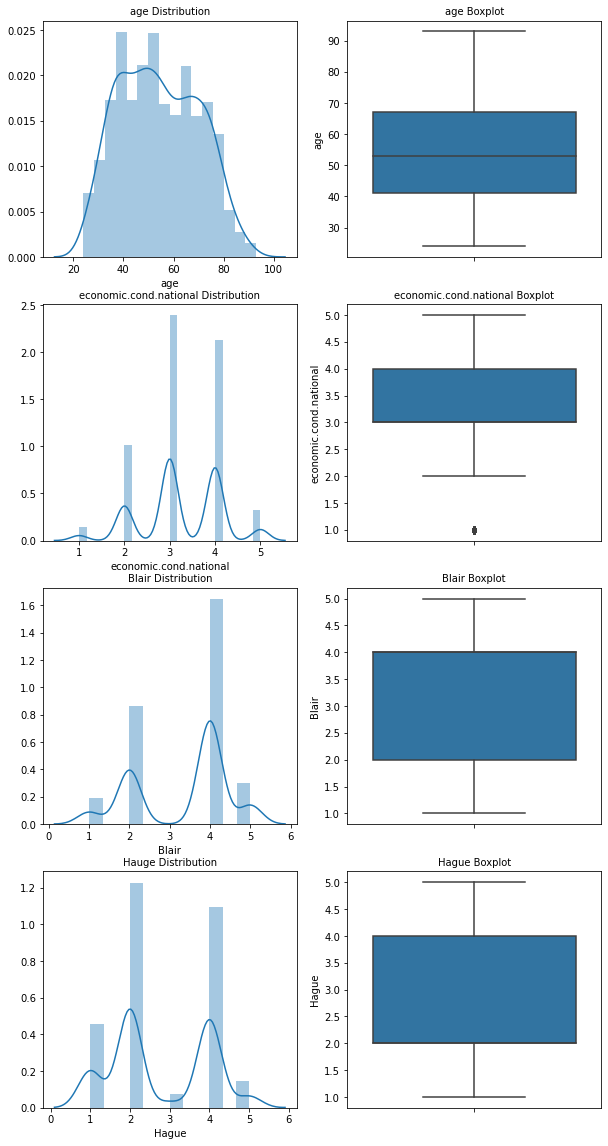

In [12]:
fig, axes = plt.subplots(nrows=4,ncols=2)
fig.set_size_inches(10,20)
a = sns.distplot(df['age'] , ax=axes[0][0])
a.set_title("age Distribution",fontsize=10)

a = sns.boxplot(df['age'] , orient = "v" , ax=axes[0][1])
a.set_title("age Boxplot",fontsize=10)

a = sns.distplot(df['economic.cond.national'] , ax=axes[1][0])
a.set_title("economic.cond.national Distribution",fontsize=10)

a = sns.boxplot(df['economic.cond.national'] , orient = "v" , ax=axes[1][1])
a.set_title("economic.cond.national Boxplot",fontsize=10)


a = sns.distplot(df['Blair'] , ax=axes[2][0])
a.set_title("Blair Distribution",fontsize=10)

a = sns.boxplot(df['Blair'] , orient = "v" , ax=axes[2][1])
a.set_title("Blair Boxplot",fontsize=10)


a = sns.distplot(df['Hague'] , ax=axes[3][0])
a.set_title("Hauge Distribution",fontsize=10)

a = sns.boxplot(df['Hague'] , orient = "v" , ax=axes[3][1])
a.set_title("Hague Boxplot",fontsize=10)



plt.show()

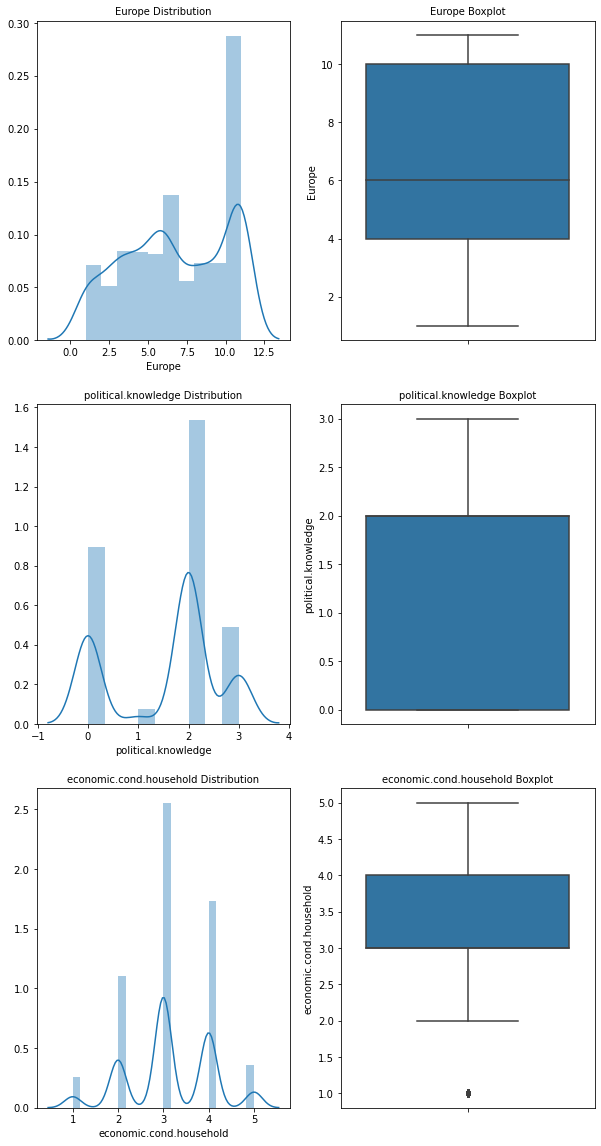

In [13]:
fig, axes = plt.subplots(nrows=3,ncols=2)
fig.set_size_inches(10,20)
a = sns.distplot(df['Europe'] , ax=axes[0][0])
a.set_title("Europe Distribution",fontsize=10)

a = sns.boxplot(df['Europe'] , orient = "v" , ax=axes[0][1])
a.set_title("Europe Boxplot",fontsize=10)

a = sns.distplot(df['political.knowledge'] , ax=axes[1][0])
a.set_title("political.knowledge Distribution",fontsize=10)

a = sns.boxplot(df['political.knowledge'] , orient = "v" , ax=axes[1][1])
a.set_title("political.knowledge Boxplot",fontsize=10)

a = sns.distplot(df['economic.cond.household'] , ax=axes[2][0])
a.set_title("economic.cond.household Distribution",fontsize=10)

a = sns.boxplot(df['economic.cond.household'] , orient = "v" , ax=axes[2][1])
a.set_title("economic.cond.household Boxplot",fontsize=10)

plt.show()

In [14]:
print("SKEWNESS")
df.skew()

SKEWNESS


age                        0.144621
economic.cond.national    -0.240453
economic.cond.household   -0.149552
Blair                     -0.535419
Hague                      0.152100
Europe                    -0.135947
political.knowledge       -0.426838
dtype: float64

In [15]:
print("KURTOSIS")
df.kurtosis()

KURTOSIS


age                       -0.946897
economic.cond.national    -0.255994
economic.cond.household   -0.206302
Blair                     -1.065582
Hague                     -1.391743
Europe                    -1.237841
political.knowledge       -1.216646
dtype: float64

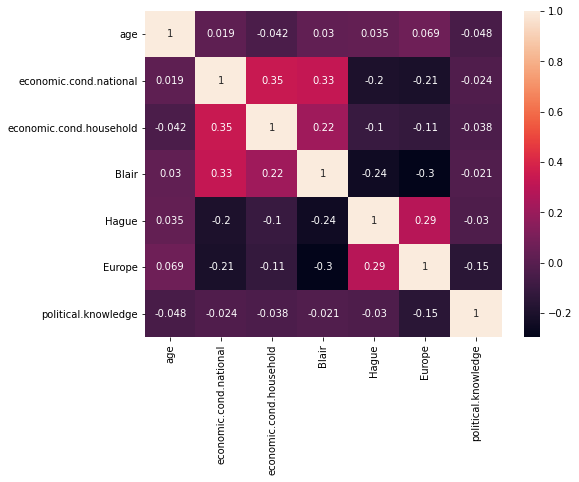

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True)
plt.show()

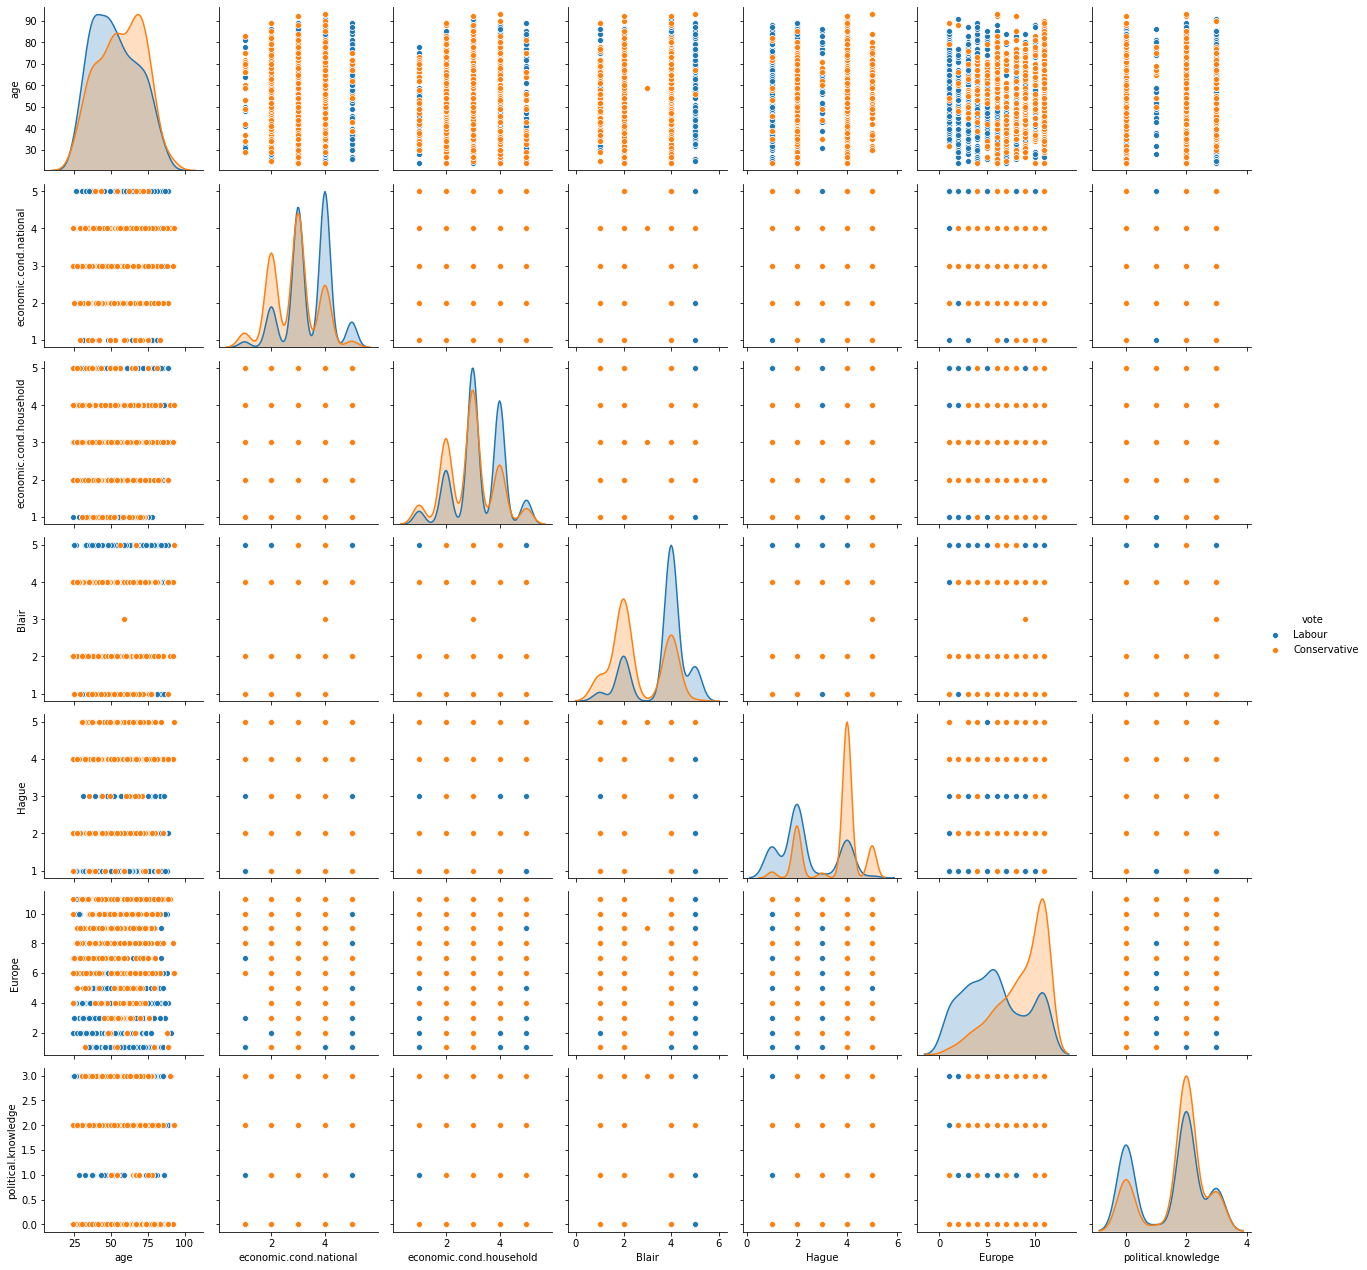

In [17]:
sns.pairplot(df,hue="vote")

In [18]:
cat=[]
num=[]
for i in df.columns:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num)

['vote', 'gender']
['age', 'economic.cond.national', 'economic.cond.household', 'Blair', 'Hague', 'Europe', 'political.knowledge']


In [19]:
df_copy=df.copy()

In [20]:
df_dummies =pd.get_dummies(df_copy, columns=cat,drop_first=True)

In [21]:
df_dummies

,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,vote_Labour,gender_male
0,43,3,3,4,1,2,2,1,0
1,36,4,4,4,4,5,2,1,1
2,35,4,4,5,2,3,2,1,1
3,24,4,2,2,1,4,0,1,0
4,41,2,2,1,1,6,2,1,1
...,...,...,...,...,...,...,...,...,...
1520,67,5,3,2,4,11,3,0,1
1521,73,2,2,4,4,8,2,0,1
1522,37,3,3,5,4,2,2,1,1
1523,61,3,3,1,4,11,2,0,1


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [23]:
X = df_dummies.drop('vote_Labour',axis=1)
Y = df_dummies.vote_Labour
test_size = 0.30
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

In [24]:
y_train.value_counts(1)

1    0.683224
0    0.316776
Name: vote_Labour, dtype: float64

In [25]:
y_test.value_counts(1)

1    0.729258
0    0.270742
Name: vote_Labour, dtype: float64

In [26]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [27]:
ytrain_predict = model.predict(X_train)
ytest_predict = model.predict(X_test)

In [28]:
ytest_predict_prob=model.predict_proba(X_test)
pd.DataFrame(ytest_predict_prob).head()

,0,1
0,0.543546,0.456454
1,0.798179,0.201821
2,0.037248,0.962752
3,0.013312,0.986688
4,0.627779,0.372221


In [29]:
model.score(X_train, y_train)

0.8369259606373008

In [30]:
from sklearn.metrics import roc_auc_score,roc_curve,classification_report,confusion_matrix,plot_confusion_matrix

AUC: 0.898


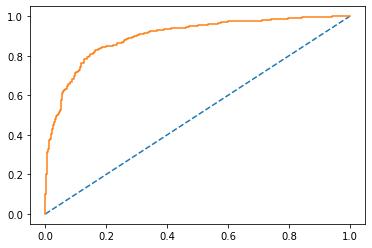

In [31]:
# predict probabilities
probs = model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

In [32]:
model.score(X_test, y_test)

0.8296943231441049

AUC: 0.898


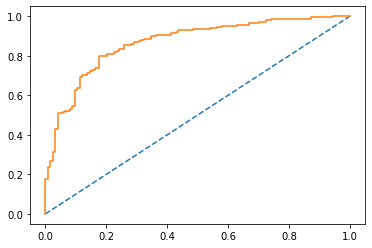

In [33]:
# predict probabilities
probs = model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
test_auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

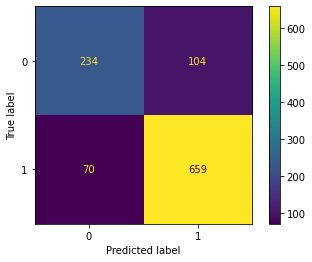

In [35]:
confusion_matrix(y_train, ytrain_predict)
plot_confusion_matrix(model,X_train,y_train);

In [57]:
print("                               Train dataset          ")
print("")
print(classification_report(y_train, ytrain_predict))

print("")
print("")
print("")

print("                               Test dataset          ")
print("")
print(classification_report(y_test, ytest_predict))

                               Train dataset          

              precision    recall  f1-score   support

           0       0.77      0.69      0.73       338
           1       0.86      0.91      0.88       729

    accuracy                           0.84      1067
   macro avg       0.82      0.80      0.81      1067
weighted avg       0.83      0.84      0.84      1067




                               Test dataset          

              precision    recall  f1-score   support

           0       0.70      0.65      0.68       124
           1       0.87      0.90      0.89       334

    accuracy                           0.83       458
   macro avg       0.79      0.78      0.78       458
weighted avg       0.83      0.83      0.83       458



In [41]:
grid={'penalty':['l2','none'],
      'solver':['sag','lbfgs'],
      'tol':[0.0001,0.00001]}

In [42]:
model = LogisticRegression(max_iter=10000,n_jobs=2)

In [43]:
from sklearn.model_selection import train_test_split,GridSearchCV

In [44]:
grid_search = GridSearchCV(estimator = model, param_grid = grid, cv = 3,n_jobs=-1,scoring='f1')

In [45]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=10000, n_jobs=2),
             n_jobs=-1,
             param_grid={'penalty': ['l2', 'none'], 'solver': ['sag', 'lbfgs'],
                         'tol': [0.0001, 1e-05]},
             scoring='f1')

In [46]:
print(grid_search.best_params_,'\n')
print(grid_search.best_estimator_)

{'penalty': 'l2', 'solver': 'sag', 'tol': 1e-05} 

LogisticRegression(max_iter=10000, n_jobs=2, solver='sag', tol=1e-05)


In [50]:
best_model_logistics = grid_search.best_estimator_

In [52]:
 #Prediction on the training set

ytrain_predict = best_model_logistics.predict(X_train)
ytest_predict = best_model_logistics.predict(X_test)

In [53]:
ytest_predict_prob=best_model_logistics.predict_proba(X_test)
pd.DataFrame(ytest_predict_prob).head()

,0,1
0,0.542907,0.457093
1,0.792101,0.207899
2,0.037315,0.962685
3,0.013722,0.986278
4,0.631295,0.368705


Train Dataset
              precision    recall  f1-score   support

           0       0.77      0.69      0.73       338
           1       0.86      0.91      0.88       729

    accuracy                           0.84      1067
   macro avg       0.82      0.80      0.81      1067
weighted avg       0.83      0.84      0.84      1067
 




Test Dataset
              precision    recall  f1-score   support

           0       0.70      0.65      0.68       124
           1       0.87      0.90      0.89       334

    accuracy                           0.83       458
   macro avg       0.79      0.78      0.78       458
weighted avg       0.83      0.83      0.83       458
 



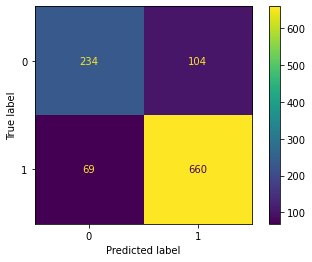

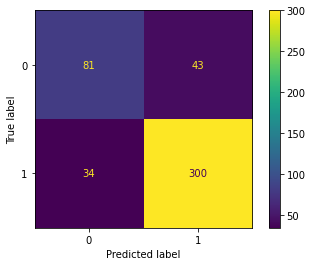

In [56]:
## Confusion matrix on the training data
print("Train Dataset")
plot_confusion_matrix(best_model_logistics,X_train,y_train)
print(classification_report(y_train, ytrain_predict),'\n');

print("")
print("")
print("")


## Confusion matrix on the test data
print("Test Dataset")
plot_confusion_matrix(best_model_logistics,X_test,y_test)
print(classification_report(y_test, ytest_predict),'\n');

AUC: 0.898


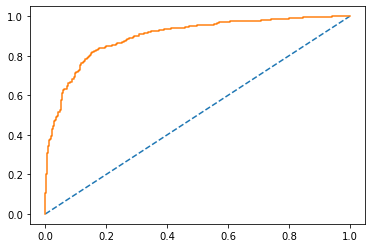

In [149]:
 #predict probabilities
probs_logistics = best_model_logistics.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_logistics = probs_logistics[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_logistics)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_logistics)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.867


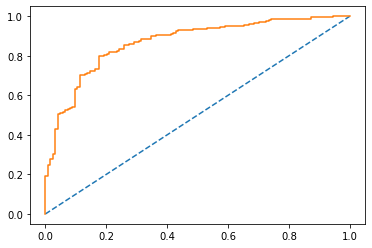

In [153]:
 #predict probabilities
probs_logistics = best_model_logistics.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_logistics = probs_logistics[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_logistics)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_logistics)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import metrics,model_selection
from sklearn.preprocessing import scale

In [59]:
clf = LinearDiscriminantAnalysis()
model_LDA=clf.fit(X_train,y_train)

In [63]:
# Training Data Class Prediction with a cut-off value of 0.5
pred_class_train_LDA = model_LDA.predict(X_train)

# Test Data Class Prediction with a cut-off value of 0.5
pred_class_test_LDA = model_LDA.predict(X_test)

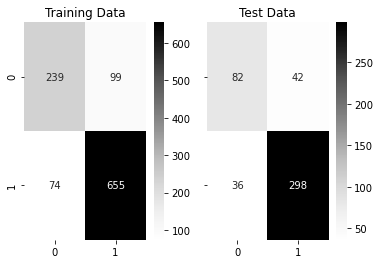

In [64]:
f,a =  plt.subplots(1,2,sharex=True,sharey=True,squeeze=False)

#Plotting confusion matrix for the different models for the Training Data

plot_0 = sns.heatmap((metrics.confusion_matrix(y_train,pred_class_train_LDA)),annot=True,fmt='.5g',cmap='Greys',ax=a[0][0]);
a[0][0].set_title('Training Data')

plot_1 = sns.heatmap((metrics.confusion_matrix(y_test,pred_class_test_LDA)),annot=True,fmt='.5g',cmap='Greys',ax=a[0][1]);
a[0][1].set_title('Test Data');

In [66]:
print('Classification Report of the training data:\n\n',metrics.classification_report(y_train,pred_class_train_LDA),'\n')
print('Classification Report of the test data:\n\n',metrics.classification_report(y_test,pred_class_test_LDA),'\n')

Classification Report of the training data:

               precision    recall  f1-score   support

           0       0.76      0.71      0.73       338
           1       0.87      0.90      0.88       729

    accuracy                           0.84      1067
   macro avg       0.82      0.80      0.81      1067
weighted avg       0.84      0.84      0.84      1067
 

Classification Report of the test data:

               precision    recall  f1-score   support

           0       0.69      0.66      0.68       124
           1       0.88      0.89      0.88       334

    accuracy                           0.83       458
   macro avg       0.79      0.78      0.78       458
weighted avg       0.83      0.83      0.83       458
 



AUC: 0.898


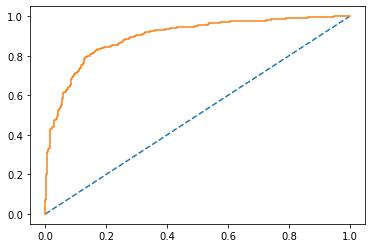

In [154]:
 #predict probabilities
probs_LDA = model_LDA.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_LDA = probs_LDA[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_LDA)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_LDA)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.868


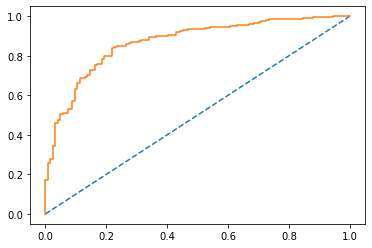

In [155]:
#predict probabilities
probs_LDA = model_LDA.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_LDA = probs_LDA[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_LDA)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_LDA)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

In [67]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [68]:
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

GaussianNB()

In [69]:
y_train_predict_NB = NB_model.predict(X_train)
model_score_NB = NB_model.score(X_train, y_train)                     
print(model_score_NB)
print(metrics.confusion_matrix(y_train, y_train_predict_NB))          
print(metrics.classification_report(y_train, y_train_predict_NB))  

0.8406747891283973
[[249  89]
 [ 81 648]]
              precision    recall  f1-score   support

           0       0.75      0.74      0.75       338
           1       0.88      0.89      0.88       729

    accuracy                           0.84      1067
   macro avg       0.82      0.81      0.81      1067
weighted avg       0.84      0.84      0.84      1067



In [70]:
y_test_predict_NB = NB_model.predict(X_test)
model_score_NBtest = NB_model.score(X_test, y_test)                    
print(model_score_NBtest)
print(metrics.confusion_matrix(y_test, y_test_predict_NB))         
print(metrics.classification_report(y_test, y_test_predict_NB)) 

0.8187772925764192
[[ 83  41]
 [ 42 292]]
              precision    recall  f1-score   support

           0       0.66      0.67      0.67       124
           1       0.88      0.87      0.88       334

    accuracy                           0.82       458
   macro avg       0.77      0.77      0.77       458
weighted avg       0.82      0.82      0.82       458



In [71]:
NB_model.score(X_train, y_train)

0.8406747891283973

In [72]:
NB_model.score(X_test, y_test)

0.8187772925764192

AUC: 0.894


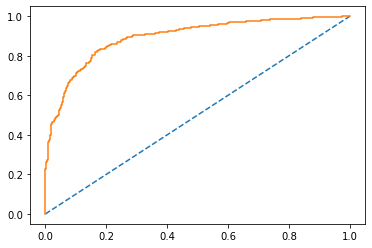

In [156]:
#predict probabilities
probs_NB = NB_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_NB = probs_NB[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_NB)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_NB)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.866


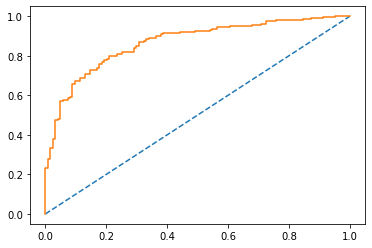

In [157]:
#predict probabilities
probs_NB = NB_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_NB = probs_NB[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_NB)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_NB)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

In [110]:
from sklearn.neighbors import KNeighborsClassifier

KNN_model=KNeighborsClassifier()
KNN_model.fit(X_train,y_train)

KNeighborsClassifier()

In [103]:
# loading library
from sklearn.neighbors import KNeighborsClassifier

# initiantiate learning model (k = 3)
KNN_model=KNeighborsClassifier(n_neighbors = 3,metric='euclidean')

# fitting the model
KNN_model.fit(X_train,y_train)

# predict the response
y_test_predict_knn = KNN_model.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=3 is ", KNN_model.score(X_test, y_test))

# initiantiate learning model (k = 5)
KNN_model=KNeighborsClassifier(n_neighbors = 4,metric='euclidean')

# fitting the model
KNN_model.fit(X_train,y_train)

# predict the response
y_test_predict_knn = KNN_model.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=5 is ", KNN_model.score(X_test, y_test))

# initiantiate learning model (k = 5)
KNN_model=KNeighborsClassifier(n_neighbors = 5,metric='euclidean')

# fitting the model
KNN_model.fit(X_train,y_train)

# predict the response
y_test_predict_knn = KNN_model.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=5 is ", KNN_model.score(X_test, y_test))

# initiantiate learning model (k = 5)
KNN_model=KNeighborsClassifier(n_neighbors = 6,metric='euclidean')

# fitting the model
KNN_model.fit(X_train,y_train)

# predict the response
y_test_predict_knn = KNN_model.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=5 is ", KNN_model.score(X_test, y_test))

# initiantiate learning model (k = 9)
from sklearn.neighbors import KNeighborsClassifier
KNN_model=KNeighborsClassifier(n_neighbors = 7,metric='euclidean')

# fitting the model
KNN_model.fit(X_train,y_train)

# predict the response
y_test_predict_knn = KNN_model.predict(X_test)

# evaluate accuracy
print("Accuracy Score for K=9 is ", KNN_model.score(X_test, y_test))

Accuracy Score for K=3 is  0.7816593886462883
Accuracy Score for K=5 is  0.7860262008733624
Accuracy Score for K=5 is  0.7816593886462883
Accuracy Score for K=5 is  0.777292576419214
Accuracy Score for K=9 is  0.8013100436681223


In [97]:
# empty list that will hold accuracy scores
ac_scores = []

# perform accuracy metrics for values from 1,3,5....19
for k in range(1,20,2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    # evaluate accuracy
    scores = knn.score(X_test, y_test)
    ac_scores.append(scores)

# changing to misclassification error
MCE = [1 - s for s in ac_scores]
MCE

[0.25109170305676853,
 0.21834061135371174,
 0.21834061135371174,
 0.1986899563318777,
 0.20087336244541487,
 0.20524017467248912,
 0.19432314410480345,
 0.19432314410480345,
 0.18777292576419213,
 0.19432314410480345]

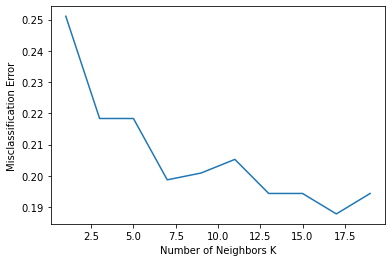

In [108]:
import matplotlib.pyplot as plt
# plot misclassification error vs k
plt.plot(range(1,20,2), MCE)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Misclassification Error')
plt.show()

In [ ]:
NNH = KNeighborsClassifier(n_neighbors= 5 , weights = 'distance' )


In [ ]:
NNH.fit(X_train, y_train)

In [ ]:
predicted_labels = NNH.predict(X_test)
NNH.score(X_test, y_test)

In [111]:
## Performance Matrix on train data set
print("Claasiication report on Train data")
y_train_predict_knn = KNN_model.predict(X_train)
model_score_knn = KNN_model.score(X_train, y_train)
print(model_score_knn)
print(metrics.confusion_matrix(y_train, y_train_predict_knn))
print(metrics.classification_report(y_train, y_train_predict_knn))


print("")
print("")
print("")

print("Claasiication report on Test data")
y_test_predict_knn = KNN_model.predict(X_test)
model_score_knn1 = KNN_model.score(X_test, y_test)
print(model_score_knn1)
print(metrics.confusion_matrix(y_test, y_test_predict_knn))
print(metrics.classification_report(y_test, y_test_predict_knn))

Claasiication report on Train data
0.8556701030927835
[[249  89]
 [ 65 664]]
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       338
           1       0.88      0.91      0.90       729

    accuracy                           0.86      1067
   macro avg       0.84      0.82      0.83      1067
weighted avg       0.85      0.86      0.85      1067




Claasiication report on Test data
0.7816593886462883
[[ 72  52]
 [ 48 286]]
              precision    recall  f1-score   support

           0       0.60      0.58      0.59       124
           1       0.85      0.86      0.85       334

    accuracy                           0.78       458
   macro avg       0.72      0.72      0.72       458
weighted avg       0.78      0.78      0.78       458



AUC: 0.929


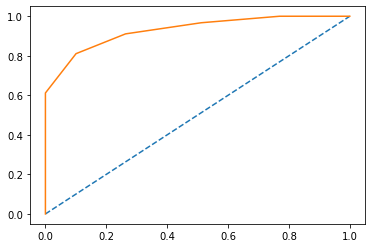

In [163]:
#predict probabilities
probs_KNN = KNN_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_KNN = probs_KNN[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_KNN)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_KNN)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.807


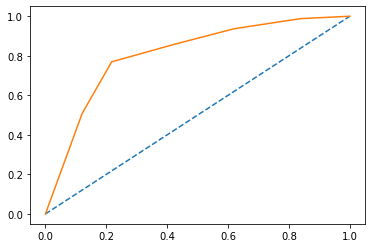

In [164]:
#predict probabilities
probs_KNN= KNN_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_KNN = probs_KNN[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_KNN)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_KNN)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

In [112]:
from sklearn.ensemble import RandomForestClassifier

RF_model=RandomForestClassifier(n_estimators=100,random_state=1)
RF_model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [113]:
## Performance Matrix on train data set
y_train_predict_rf = RF_model.predict(X_train)
model_score_rf =RF_model.score(X_train, y_train)
print(model_score_rf)
print(metrics.confusion_matrix(y_train, y_train_predict_rf))
print(metrics.classification_report(y_train, y_train_predict_rf))

1.0
[[338   0]
 [  0 729]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       338
           1       1.00      1.00      1.00       729

    accuracy                           1.00      1067
   macro avg       1.00      1.00      1.00      1067
weighted avg       1.00      1.00      1.00      1067



In [115]:
## Performance Matrix on test data set
y_test_predict_rf = RF_model.predict(X_test)
model_score_rf1= RF_model.score(X_test, y_test)
print(model_score_rf1)
print(metrics.confusion_matrix(y_test, y_test_predict_rf))
print(metrics.classification_report(y_test, y_test_predict_rf))

0.8144104803493449
[[ 79  45]
 [ 40 294]]
              precision    recall  f1-score   support

           0       0.66      0.64      0.65       124
           1       0.87      0.88      0.87       334

    accuracy                           0.81       458
   macro avg       0.77      0.76      0.76       458
weighted avg       0.81      0.81      0.81       458



In [116]:
from sklearn.ensemble import BaggingClassifier

Random_forest = RandomForestClassifier()
Bagging_model=BaggingClassifier(base_estimator=Random_forest,n_estimators=100,random_state=1)
Bagging_model.fit(X_train, y_train)

BaggingClassifier(base_estimator=RandomForestClassifier(), n_estimators=100,
                  random_state=1)

In [117]:
## Performance Matrix on train data set
y_train_predict_bagging = Bagging_model.predict(X_train)
model_score_bagging =Bagging_model.score(X_train, y_train)
print(model_score_bagging)
print(metrics.confusion_matrix(y_train, y_train_predict_bagging))
print(metrics.classification_report(y_train, y_train_predict_bagging))

0.9709465791940018
[[318  20]
 [ 11 718]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       338
           1       0.97      0.98      0.98       729

    accuracy                           0.97      1067
   macro avg       0.97      0.96      0.97      1067
weighted avg       0.97      0.97      0.97      1067



In [118]:
## Performance Matrix on test data set
y_test_predict_bagging = Bagging_model.predict(X_test)
model_score_bagging1 = Bagging_model.score(X_test, y_test)
print(model_score_bagging1)
print(metrics.confusion_matrix(y_test, y_test_predict_bagging))
print(metrics.classification_report(y_test, y_test_predict_bagging))

0.8318777292576419
[[ 79  45]
 [ 32 302]]
              precision    recall  f1-score   support

           0       0.71      0.64      0.67       124
           1       0.87      0.90      0.89       334

    accuracy                           0.83       458
   macro avg       0.79      0.77      0.78       458
weighted avg       0.83      0.83      0.83       458



AUC: 0.998


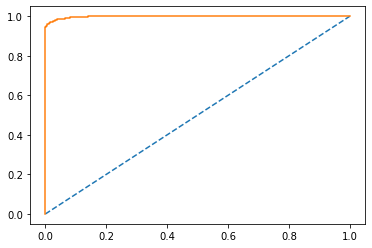

In [165]:
#predict probabilities
probs_Bagging= Bagging_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_Bagging = probs_Bagging[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_Bagging)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_Bagging)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.877


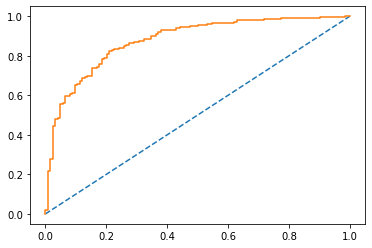

In [166]:
#predict probabilities
probs_Bagging= Bagging_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_Bagging = probs_Bagging[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_Bagging)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_Bagging)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

In [119]:
from sklearn.ensemble import AdaBoostClassifier


ADB_model = AdaBoostClassifier(n_estimators=100,random_state=1)
ADB_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=1)

In [120]:
## Performance Matrix on train data set
y_train_predict_ada = ADB_model.predict(X_train)
model_score_ada = ADB_model.score(X_train, y_train)
print(model_score_ada)
print(metrics.confusion_matrix(y_train, y_train_predict_ada))
print(metrics.classification_report(y_train, y_train_predict_ada))

0.8528584817244611
[[250  88]
 [ 69 660]]
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       338
           1       0.88      0.91      0.89       729

    accuracy                           0.85      1067
   macro avg       0.83      0.82      0.83      1067
weighted avg       0.85      0.85      0.85      1067



In [121]:
## Performance Matrix on test data set
y_test_predict_ada = ADB_model.predict(X_test)
model_score_ada1= ADB_model.score(X_test, y_test)
print(model_score_ada1)
print(metrics.confusion_matrix(y_test, y_test_predict_ada))
print(metrics.classification_report(y_test, y_test_predict_ada))

0.8384279475982532
[[ 82  42]
 [ 32 302]]
              precision    recall  f1-score   support

           0       0.72      0.66      0.69       124
           1       0.88      0.90      0.89       334

    accuracy                           0.84       458
   macro avg       0.80      0.78      0.79       458
weighted avg       0.83      0.84      0.84       458



AUC: 0.921


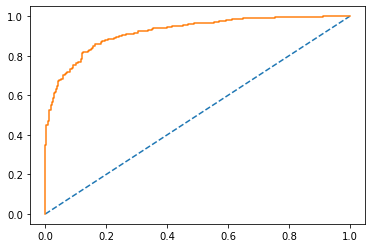

In [169]:
#predict probabilities
probs_ADB= ADB_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_ADB = probs_ADB[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_ADB)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_ADB)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.856


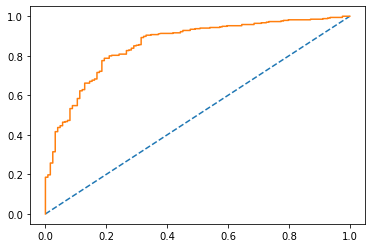

In [168]:
#predict probabilities
probs_ADB= ADB_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_ADB = probs_ADB[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_ADB)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_ADB)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

In [122]:
from sklearn.ensemble import GradientBoostingClassifier
gbcl = GradientBoostingClassifier(random_state=1)
gbcl = gbcl.fit(X_train, y_train)

In [123]:
## Performance Matrix on train data set
y_train_predict_grad = gbcl.predict(X_train)
model_score_grad= gbcl.score(X_train, y_train)
print(model_score_grad)
print(metrics.confusion_matrix(y_train, y_train_predict_grad))
print(metrics.classification_report(y_train, y_train_predict_grad))

0.8894095595126523
[[272  66]
 [ 52 677]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       338
           1       0.91      0.93      0.92       729

    accuracy                           0.89      1067
   macro avg       0.88      0.87      0.87      1067
weighted avg       0.89      0.89      0.89      1067



In [124]:
## Performance Matrix on test data set
y_test_predict_grad= gbcl.predict(X_test)
model_score_grad1 = gbcl.score(X_test, y_test)
print(model_score_grad1)
print(metrics.confusion_matrix(y_test, y_test_predict_grad))
print(metrics.classification_report(y_test, y_test_predict_grad))

0.8318777292576419
[[ 81  43]
 [ 34 300]]
              precision    recall  f1-score   support

           0       0.70      0.65      0.68       124
           1       0.87      0.90      0.89       334

    accuracy                           0.83       458
   macro avg       0.79      0.78      0.78       458
weighted avg       0.83      0.83      0.83       458



AUC: 0.921


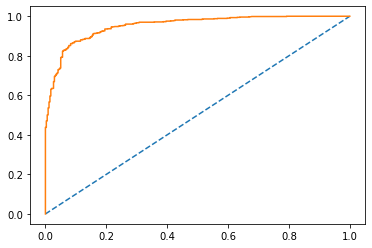

In [170]:
#predict probabilities
probs_gbcl= gbcl.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_gbcl = probs_gbcl[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_ADB)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_gbcl)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.880


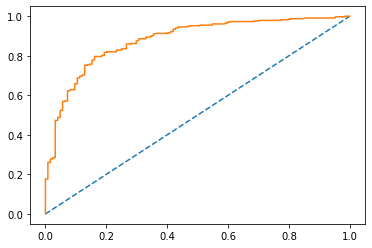

In [172]:
#predict probabilities
probs_gbcl= gbcl.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_gbcl = probs_gbcl[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_gbcl)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_gbcl)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

In [125]:
## !pip install imbalanced-learn

In [130]:
from imblearn.over_sampling import SMOTE

In [132]:
sm = SMOTE(random_state=2)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train.ravel())

In [133]:
X_train_res.shape

(1458, 8)

In [134]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [135]:
NB_SM_model = GaussianNB()
NB_SM_model.fit(X_train_res, y_train_res)

GaussianNB()

In [136]:
## Performance Matrix on train data set with SMOTE
y_train_predict_SM= NB_SM_model.predict(X_train_res)
model_score_SM = NB_SM_model.score(X_train_res, y_train_res)
print(model_score_SM)
print(metrics.confusion_matrix(y_train_res, y_train_predict_SM))
print(metrics.classification_report(y_train_res ,y_train_predict_SM))

0.8326474622770919
[[607 122]
 [122 607]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       729
           1       0.83      0.83      0.83       729

    accuracy                           0.83      1458
   macro avg       0.83      0.83      0.83      1458
weighted avg       0.83      0.83      0.83      1458



In [137]:
## Performance Matrix on test data set
y_test_predict_SM = NB_SM_model.predict(X_test)
model_score_SM1 = NB_SM_model.score(X_test, y_test)
print(model_score_SM1)
print(metrics.confusion_matrix(y_test, y_test_predict_SM))
print(metrics.classification_report(y_test, y_test_predict_SM))

0.7925764192139738
[[ 88  36]
 [ 59 275]]
              precision    recall  f1-score   support

           0       0.60      0.71      0.65       124
           1       0.88      0.82      0.85       334

    accuracy                           0.79       458
   macro avg       0.74      0.77      0.75       458
weighted avg       0.81      0.79      0.80       458



AUC: 0.888


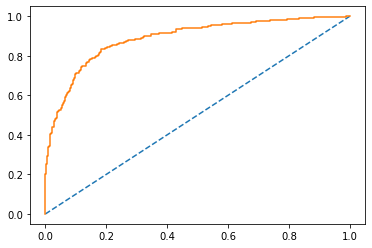

In [173]:
#predict probabilities
probs_NBSM= NB_SM_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_NBSM = probs_NBSM[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_NBSM)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_NBSM)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.860


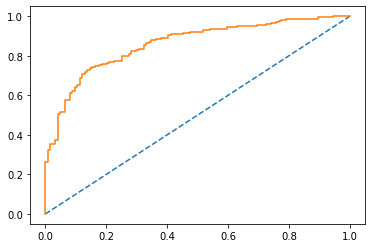

In [175]:
#predict probabilities
probs_NBSM= NB_SM_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_NBSM = probs_NBSM[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_NBSM)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_NBSM)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);

In [138]:
from sklearn.neighbors import KNeighborsClassifier

KNN_SM_model=KNeighborsClassifier()
KNN_SM_model.fit(X_train_res,y_train_res)

KNeighborsClassifier()

In [139]:
## Performance Matrix on train data set
y_train_predict_SM = KNN_SM_model.predict(X_train_res)
model_score_SM1 = KNN_SM_model.score(X_train_res, y_train_res)
print(model_score_SM1)
print(metrics.confusion_matrix(y_train_res, y_train_predict_SM))
print(metrics.classification_report(y_train_res, y_train_predict_SM))

0.8950617283950617
[[698  31]
 [122 607]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       729
           1       0.95      0.83      0.89       729

    accuracy                           0.90      1458
   macro avg       0.90      0.90      0.89      1458
weighted avg       0.90      0.90      0.89      1458



In [140]:
## Performance Matrix on test data set
y_test_predict_SM = KNN_SM_model.predict(X_test)
model_score_SM2 = KNN_SM_model.score(X_test, y_test)
print(model_score_SM2)
print(metrics.confusion_matrix(y_test, y_test_predict_SM))
print(metrics.classification_report(y_test, y_test_predict_SM))

0.7685589519650655
[[ 92  32]
 [ 74 260]]
              precision    recall  f1-score   support

           0       0.55      0.74      0.63       124
           1       0.89      0.78      0.83       334

    accuracy                           0.77       458
   macro avg       0.72      0.76      0.73       458
weighted avg       0.80      0.77      0.78       458



AUC: 0.954


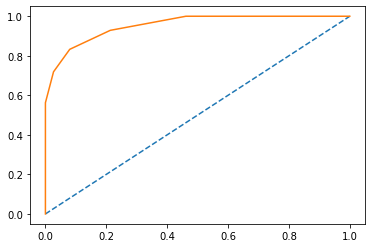

In [177]:
#predict probabilities
probs_KNNSM= KNN_SM_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs_KNNSM = probs_KNNSM[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs_KNNSM)
print('AUC: %.3f' % auc)
# calculate roc curve
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs_KNNSM)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(train_fpr, train_tpr);

AUC: 0.809


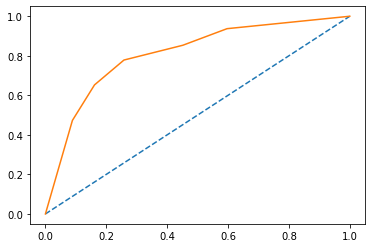

In [178]:
#predict probabilities
probs_KNNSM= KNN_SM_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs_KNNSM = probs_KNNSM[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs_KNNSM)
print('AUC: %.3f' % auc)
# calculate roc curve
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs_KNNSM)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(test_fpr, test_tpr);